In [22]:
import tensorflow
from tensorflow import keras
from keras.layers import SimpleRNN,Dense,Embedding,LSTM
from keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt


#zero padding technique

In [23]:
import numpy as np

docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token='<nothing>')
tokenizer.fit_on_texts(docs)

In [25]:
tokenizer.word_index

{'<nothing>': 1,
 'india': 2,
 'jeetega': 3,
 'hip': 4,
 'ki': 5,
 'jai': 6,
 'kohli': 7,
 'sachin': 8,
 'dhoni': 9,
 'go': 10,
 'hurray': 11,
 'bhai': 12,
 'bharat': 13,
 'mata': 14,
 'modi': 15,
 'ji': 16,
 'inquilab': 17,
 'zindabad': 18}

In [26]:
tokenizer.word_counts

OrderedDict([('go', 1),
             ('india', 4),
             ('hip', 2),
             ('hurray', 1),
             ('jeetega', 3),
             ('bhai', 1),
             ('bharat', 1),
             ('mata', 1),
             ('ki', 2),
             ('jai', 2),
             ('kohli', 2),
             ('sachin', 2),
             ('dhoni', 2),
             ('modi', 1),
             ('ji', 1),
             ('inquilab', 1),
             ('zindabad', 1)])

In [27]:
tokenizer.document_count

10

In [28]:
seq=tokenizer.texts_to_sequences(docs)

In [29]:
seq

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

In [30]:
from keras.utils import pad_sequences

In [31]:
seq=pad_sequences(seq,padding='post')

In [32]:
seq

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]], dtype=int32)

In [33]:
from keras.datasets import imdb


In [34]:
(x_train,y_train),(x_test,y_test)=imdb.load_data()

In [35]:
#it is an processed dataset
x_train.shape

(25000,)

In [36]:
x_test.shape

(25000,)

In [37]:
len(x_train[0])

218

In [38]:
x_train=pad_sequences(x_train,padding='post')#picche zero lagayega
x_test=pad_sequences(x_test,padding='post')

In [39]:
x_test[0]

array([  1, 591, 202, ...,   0,   0,   0], shape=(2315,), dtype=int32)

In [40]:
x_test[0]

array([  1, 591, 202, ...,   0,   0,   0], shape=(2315,), dtype=int32)

In [81]:
model =Sequential()
model.add(SimpleRNN(32,input_shape=(2494,1),activation='tanh',return_sequences=False))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
hsitory=model.fit(x_train,y_train,epochs=15,validation_data=(x_test,y_test))

Epoch 1/15
 12/782 ━━━━━━━━━━━━━━━━━━━━ 2:43 213ms/step - accuracy: 0.4249 - loss: 0.7012

KeyboardInterrupt: 

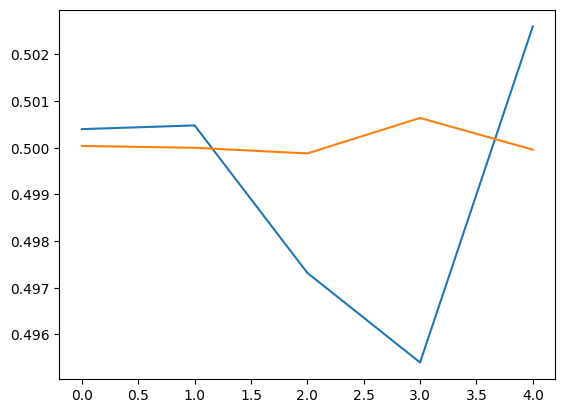

In [ ]:
plt.plot(hsitory.history['accuracy'],label='acc')
plt.plot(hsitory.history['val_accuracy'],label='val')

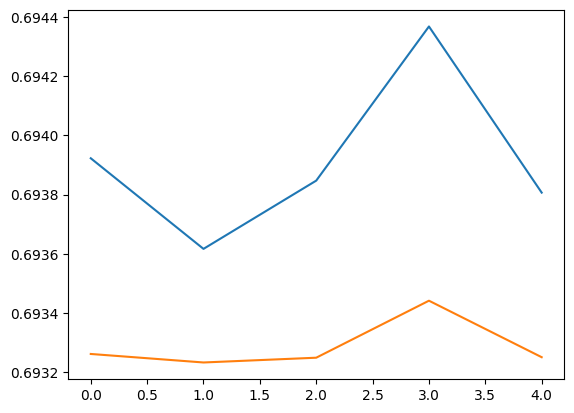

In [ ]:
plt.plot(hsitory.history['loss'],label='loss')
plt.plot(hsitory.history['val_loss'],label='val')

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer()
tokenizer.fit_on_texts(docs)

In [22]:
len(tokenizer.word_index)

17

In [23]:
tokenizer.word_counts

OrderedDict([('go', 1),
             ('india', 4),
             ('hip', 2),
             ('hurray', 1),
             ('jeetega', 3),
             ('bhai', 1),
             ('bharat', 1),
             ('mata', 1),
             ('ki', 2),
             ('jai', 2),
             ('kohli', 2),
             ('sachin', 2),
             ('dhoni', 2),
             ('modi', 1),
             ('ji', 1),
             ('inquilab', 1),
             ('zindabad', 1)])

In [24]:
seq=tokenizer.texts_to_sequences(docs)

In [25]:
seq

[[9, 1],
 [1, 1],
 [3, 3, 10],
 [2, 11, 2, 1, 2],
 [12, 13, 4, 5],
 [6, 6],
 [7, 7],
 [8, 8],
 [14, 15, 4, 5],
 [16, 17]]

In [27]:
from keras.utils import pad_sequences
seq=pad_sequences(seq,padding='post')
seq

array([[ 9,  1,  0,  0,  0],
       [ 1,  1,  0,  0,  0],
       [ 3,  3, 10,  0,  0],
       [ 2, 11,  2,  1,  2],
       [12, 13,  4,  5,  0],
       [ 6,  6,  0,  0,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [14, 15,  4,  5,  0],
       [16, 17,  0,  0,  0]], dtype=int32)

In [41]:
model=Sequential()
model.add(Embedding(18,output_dim=2,input_shape=(5,)))
#no of word unique vocalbulary , op of dim if 2 in each word represnt in 2 dim ,inout len
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 5, 2)           │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36 (144.00 B)

 Trainable params: 36 (144.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile('adam','accuracy')
pred=model.predict(seq)
print(pred)

InvalidArgumentError: Graph execution error:

Detected at node sequential_1/embedding_1/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Python313\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Python313\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Python313\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Python313\Lib\asyncio\base_events.py", line 677, in run_forever

  File "c:\Python313\Lib\asyncio\base_events.py", line 2034, in _run_once

  File "c:\Python313\Lib\asyncio\events.py", line 89, in _run

  File "c:\Python313\Lib\site-packages\ipykernel\kernelbase.py", line 545, in dispatch_queue

  File "c:\Python313\Lib\site-packages\ipykernel\kernelbas

In [42]:
model3=Sequential()
model3.add(Embedding(100000,32,input_shape=(50,)))
model3.add(LSTM(64))
model3.add(Dense(1,activation='sigmoid'))

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 32)         │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,224,897 (12.30 MB)

 Trainable params: 3,224,897 (12.30 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model3.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
hsitory=modefl3.fit(x_train,y_train,epochs=15,validation_data=(x_test,y_test))

Epoch 1/15
 88/782 ━━━━━━━━━━━━━━━━━━━━ 14:49 1s/step - accuracy: 0.5032 - loss: 0.6942

KeyboardInterrupt: 

In [ ]:
np.max(x_train)

np.int32(38275)

In [74]:
print(x_train.shape)

(25000, 50)
